In [1]:
!pip install pyspark
!pip install findspark

import matplotlib.pyplot as plt
from collections import Counter

In [2]:
#Initialize Spark Session
import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("SentimentAnalysis") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark

spark.sparkContext.setLogLevel("ERROR")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/20 23:27:01 WARN Utils: Your hostname, tirtho-B450M-DS3H-WIFI, resolves to a loopback address: 127.0.1.1; using 192.168.1.33 instead (on interface enp4s0)
26/04/20 23:27:01 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/20 23:27:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
#Load Dataset (Sentiment140)
# Load CSV dataset
df = spark.read.csv("/home/tirtho/Downloads/sentiment140 dataset/training.1600000.processed.noemoticon.csv",
                    inferSchema=True,
                    header=False)

df.show(10)

[Stage 1:====>                                                    (1 + 11) / 12]

+---+----------+--------------------+--------+---------------+--------------------+
|_c0|       _c1|                 _c2|     _c3|            _c4|                 _c5|
+---+----------+--------------------+--------+---------------+--------------------+
|  0|1467810369|Mon Apr 06 22:19:...|NO_QUERY|_TheSpecialOne_|@switchfoot http:...|
|  0|1467810672|Mon Apr 06 22:19:...|NO_QUERY|  scotthamilton|is upset that he ...|
|  0|1467810917|Mon Apr 06 22:19:...|NO_QUERY|       mattycus|@Kenichan I dived...|
|  0|1467811184|Mon Apr 06 22:19:...|NO_QUERY|        ElleCTF|my whole body fee...|
|  0|1467811193|Mon Apr 06 22:19:...|NO_QUERY|         Karoli|@nationwideclass ...|
|  0|1467811372|Mon Apr 06 22:20:...|NO_QUERY|       joy_wolf|@Kwesidei not the...|
|  0|1467811592|Mon Apr 06 22:20:...|NO_QUERY|        mybirch|         Need a hug |
|  0|1467811594|Mon Apr 06 22:20:...|NO_QUERY|           coZZ|@LOLTrish hey  lo...|
|  0|1467811795|Mon Apr 06 22:20:...|NO_QUERY|2Hood4Hollywood|@Tatiana_K nop

In [4]:
#Assign Column Names
columns = ["sentiment", "id", "date", "query", "user", "text"]
df = df.toDF(*columns)

df.select("sentiment", "text").show(10)

+---------+--------------------+
|sentiment|                text|
+---------+--------------------+
|        0|@switchfoot http:...|
|        0|is upset that he ...|
|        0|@Kenichan I dived...|
|        0|my whole body fee...|
|        0|@nationwideclass ...|
|        0|@Kwesidei not the...|
|        0|         Need a hug |
|        0|@LOLTrish hey  lo...|
|        0|@Tatiana_K nope t...|
|        0|@twittera que me ...|
+---------+--------------------+
only showing top 10 rows


In [5]:
#Data Cleaning
from pyspark.sql.functions import col, lower, regexp_replace

# Convert to lowercase
df = df.withColumn("text", lower(col("text")))

# Remove URLs, special characters
df = df.withColumn("text", regexp_replace("text", r"http\S+", ""))
df = df.withColumn("text", regexp_replace("text", r"[^a-zA-Z\s]", ""))

df.select("text").show(10)

+--------------------+
|                text|
+--------------------+
|switchfoot   awww...|
|is upset that he ...|
|kenichan i dived ...|
|my whole body fee...|
|nationwideclass n...|
|kwesidei not the ...|
|         need a hug |
|loltrish hey  lon...|
|tatianak nope the...|
|twittera que me m...|
+--------------------+
only showing top 10 rows


In [6]:
#Convert Labels (0 → Negative, 4 → Positive)
from pyspark.sql.functions import when

df = df.withColumn("label", when(col("sentiment") == 4, 1).otherwise(0))

df.select("sentiment", "label").show(10)

+---------+-----+
|sentiment|label|
+---------+-----+
|        0|    0|
|        0|    0|
|        0|    0|
|        0|    0|
|        0|    0|
|        0|    0|
|        0|    0|
|        0|    0|
|        0|    0|
|        0|    0|
+---------+-----+
only showing top 10 rows


In [7]:
#Text Processing Pipeline Using Apache Spark MLlib
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer

# Tokenization
tokenizer = Tokenizer(inputCol="text", outputCol="words")

# Remove stopwords
remover = StopWordsRemover(inputCol="words", outputCol="filtered")

# Convert to numeric features
vectorizer = CountVectorizer(inputCol="filtered", outputCol="features")

In [8]:
#Train-Test Split
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

In [9]:
#Model 1 — Logistic Regression
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

lr = LogisticRegression(featuresCol="features", labelCol="label")

pipeline_lr = Pipeline(stages=[tokenizer, remover, vectorizer, lr])

model_lr = pipeline_lr.fit(train_df)

In [10]:
#Predictions
predictions = model_lr.transform(test_df)

predictions.select("text", "label", "prediction").show(10)

+--------------------+-----+----------+
|                text|label|prediction|
+--------------------+-----+----------+
|kenichan i dived ...|    0|       0.0|
|         need a hug |    0|       0.0|
|tatianak nope the...|    0|       0.0|
|octolinz it it co...|    0|       0.0|
|fakerpattypattz o...|    0|       1.0|
|this week is not ...|    0|       0.0|
|meh almost lover ...|    0|       0.0|
|ok im sick and sp...|    0|       0.0|
|viennah yay im ha...|    0|       1.0|
|just checked my u...|    0|       0.0|
+--------------------+-----+----------+
only showing top 10 rows


In [11]:
#Evaluation
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql.functions import udf, col
from pyspark.ml.linalg import Vectors, VectorUDT

def create_binary_prob_vector(prob_vector):
    if prob_vector is not None and len(prob_vector) == 1:
        prob_positive = prob_vector[0]
        return Vectors.dense([1 - prob_positive, prob_positive])
    elif prob_vector is not None and len(prob_vector) == 2:
        return prob_vector
    else:
        # Default to a neutral probability if vector is None or empty
        return Vectors.dense([0.5, 0.5])

create_prob_udf = udf(create_binary_prob_vector, VectorUDT())

predictions_fixed = predictions.withColumn("fixedProbability", create_prob_udf(col("probability")))

evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="fixedProbability")

accuracy = evaluator.evaluate(predictions_fixed)

print("Accuracy:", accuracy)


Accuracy: 0.7991320058705041


In [12]:
#Model 2 — Naïve Bayes
from pyspark.ml.classification import NaiveBayes

nb = NaiveBayes(featuresCol="features", labelCol="label")

pipeline_nb = Pipeline(stages=[tokenizer, remover, vectorizer, nb])

model_nb = pipeline_nb.fit(train_df)

pred_nb = model_nb.transform(test_df)

# Apply the UDF to create a new, properly formatted probability column for Naive Bayes predictions
pred_nb_fixed = pred_nb.withColumn("fixedProbability", create_prob_udf(col("probability")))

accuracy_nb = evaluator.evaluate(pred_nb_fixed)

print("Naive Bayes Accuracy:", accuracy_nb)

Naive Bayes Accuracy: 0.8492038526579031


In [13]:
#Compare Models
print("Logistic Regression Accuracy:", accuracy)
print("Naive Bayes Accuracy:", accuracy_nb)

Logistic Regression Accuracy: 0.7991320058705041
Naive Bayes Accuracy: 0.8492038526579031


In [14]:
#Save Model 
model_lr.write().overwrite().save("sentiment_model")

In [15]:
#Sample Prediction
sample = spark.createDataFrame([
    (0, "I love this product"),
    (0, "This is the worst experience ever")
], ["label", "text"])

result = model_lr.transform(sample)

result.select("text", "prediction").show()

+--------------------+----------+
|                text|prediction|
+--------------------+----------+
| I love this product|       1.0|
|This is the worst...|       0.0|
+--------------------+----------+



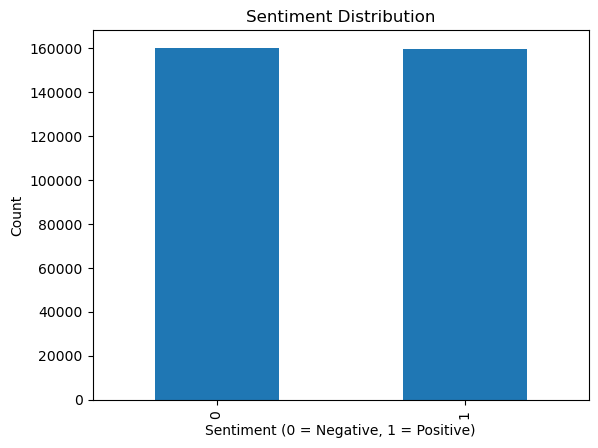

In [16]:
pdf = predictions.select("label", "text").toPandas()

sentiment_counts = pdf["label"].value_counts()

plt.figure()
sentiment_counts.plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.show()

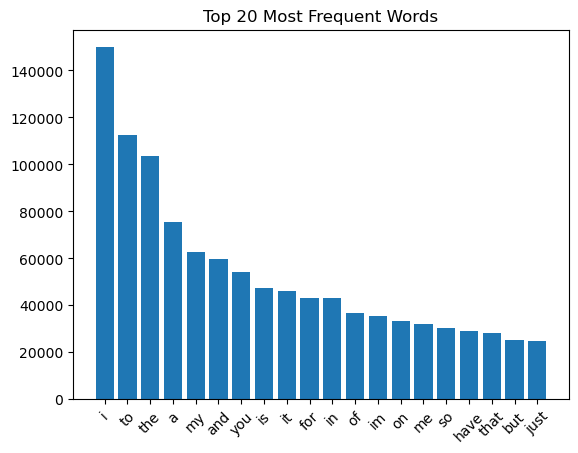

In [17]:
all_words = " ".join(pdf["text"]).split()
word_freq = Counter(all_words)

# Top 20 words
top_words = word_freq.most_common(20)

words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

plt.figure()
plt.bar(words, counts)
plt.title("Top 20 Most Frequent Words")
plt.xticks(rotation=45)
plt.show()


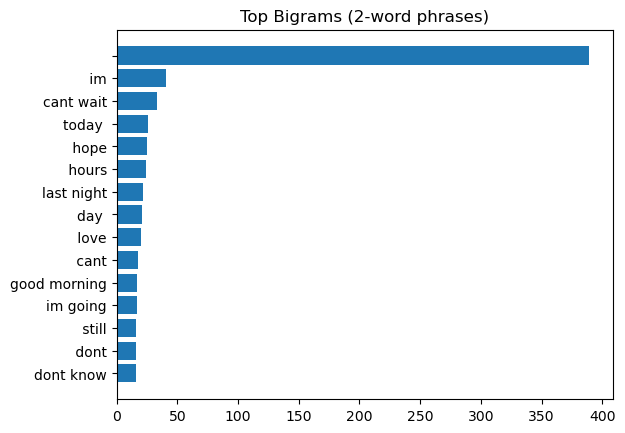

In [18]:
from pyspark.ml.feature import NGram

# Use correct column name
ngram = NGram(n=2, inputCol="filtered", outputCol="bigrams")

ngram_df = ngram.transform(predictions)

# Sample for visualization
pdf_ngram = ngram_df.select("bigrams").sample(0.01, seed=42).toPandas()

from collections import Counter

bigrams = [item for sublist in pdf_ngram["bigrams"] for item in sublist]
bigram_freq = Counter(bigrams).most_common(15)

w = [i[0] for i in bigram_freq]
c = [i[1] for i in bigram_freq]

import matplotlib.pyplot as plt

plt.figure()
plt.barh(w, c)
plt.title("Top Bigrams (2-word phrases)")
plt.gca().invert_yaxis()
plt.show()

In [19]:
#random forest  using sampled down data due to system restrictions

from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline

# 1. sample size 5% of total
train_df_mid = train_df.sample(False, 0.05, seed=42)


rf = RandomForestClassifier(
    featuresCol="features", 
    labelCol="label", 
    numTrees=20, 
    maxDepth=10,
    cacheNodeIds=True  
)

pipeline_rf = Pipeline(stages=[tokenizer, remover, vectorizer, rf])

# Train
model_rf = pipeline_rf.fit(train_df_mid)

# Predict
pred_rf = model_rf.transform(test_df)

In [20]:

# RANDOM FOREST


#from pyspark.ml.classification import RandomForestClassifier
#from pyspark.ml import Pipeline

#rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=50)

#pipeline_rf = Pipeline(stages=[tokenizer, remover, vectorizer, rf])

# Train
#model_rf = pipeline_rf.fit(train_df)

# Predict
#pred_rf = model_rf.transform(test_df)

In [21]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Initialize the evaluator
evaluator_rf = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

def get_metrics(pred):
    acc = evaluator_rf.evaluate(pred, {evaluator_rf.metricName: "accuracy"})
    f1 = evaluator_rf.evaluate(pred, {evaluator_rf.metricName: "f1"})
    return acc, f1

# Calculate and print results
acc_rf, f1_rf = get_metrics(pred_rf)

print(f"Random Forest -> Accuracy: {acc_rf:.4f}, F1: {f1_rf:.4f}")

[Stage 391:>                                                      (0 + 12) / 12]

Random Forest -> Accuracy: 0.6580, F1: 0.6501
